# Exploratory Data Analysis (EDA) - Univariate Analysis

Exploratory Data Analysis (EDA) is the process of analyzing a dataset to summarize its main characteristics, often using visual methods. In this guide, we dive into **Univariate Analysis**—the inspection of a single variable (column) in isolation.

---

## 1. Univariate Analysis Architecture

When performing univariate analysis, the first step is identifying the data type of the column. Different data types require different statistical metrics and visualization techniques:

```mermaid
graph TD
    A["Univariate Analysis"] --> B["Categorical Variables"]
    A --> C["Numerical Variables"]

    B --> B1["Frequency Check: value_counts"]
    B --> B2["Visualization: Count Plot"]
    B --> B3["Proportion Check: Pie Chart"]

    C --> C1["Visual Shape: Histogram / Bins"]
    C --> C2["Smooth Density: KDE Plot / PDF"]
    C --> C3["Spread & Outliers: Box Plot"]
    C --> C4["Stats: Mean, Median, Skew, Kurtosis"]

    style A fill:#bbf,stroke:#333,stroke-width:2px
    style B fill:#ffd,stroke:#333,stroke-width:1px
    style C fill:#dff,stroke:#333,stroke-width:1px
```

---

## 2. Analyzing Categorical Variables

Categorical variables represent discrete groups or labels (e.g., `Survived`, `Pclass`, `Sex`, `Embarked`).

### 2.1. Frequency Count & Bar Plot (`sns.countplot`)

A Count Plot shows the frequency (count) of values in each category using bars.

- **Pandas equivalent**: `df['col'].value_counts().plot(kind='bar')`
- **Seaborn equivalent**: `sns.countplot(data=df, x='col')`

### 2.2. Proportional Distribution (`plt.pie`)

Pie charts show the relative percentage of each category out of the total.

- **Pandas code**:



<Axes: >

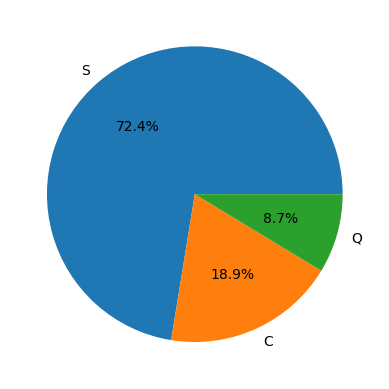

In [1]:
import pandas as pd
df = pd.read_csv("../data/titanic.csv")
df['Embarked'].value_counts().plot(kind='pie', autopct='%1.1f%%')



---

## 3. Analyzing Numerical Variables

Numerical variables represent continuous or discrete quantities (e.g., `Age`, `Fare`).

### 3.1. Frequency Distribution: Histogram

A histogram groups continuous values into range-intervals called **bins** and plots the frequency of values falling inside each bin.

- **Binning Sensitivity**: If the number of bins is too small, the details are smoothed out. If the bins are too large, the plot becomes noisy and jagged.

### 3.2. Probability Density Function: KDE (Kernel Density Estimation)

KDE estimates the probability density function (PDF) of a continuous variable. The y-axis represents **probability density**, and the total area under the curve equals $1$.

- **Interpretation**: If you pick a random passenger, the peak of the KDE curve indicates the value range they are most likely to belong to.
- **Python Code**: `sns.kdeplot(df['Age'])` or `sns.histplot(df['Age'], kde=True)`

### 3.3. Outliers & Spread: Box Plot

The Box Plot (Whisker Plot) visualizes the **five-number summary** (minimum, Q1, median, Q3, maximum) and identifies outliers mathematically.

```mermaid
box-chart
    title Box Plot Visual Anatomy
    %% Representing the box plot components textually
    %% Lower Whisker |--- [ Q1 === Median === Q3 ] ---| Upper Whisker  * (Outliers)
```

#### Mathematical Formulation of Box Plot Fences

1. **Interquartile Range (IQR)**: The distance between the 75th percentile ($Q_3$) and the 25th percentile ($Q_1$).
    $$\text{IQR} = Q_3 - Q_1$$
2. **Lower Fence**: The threshold below which a data point is flagged as a lower outlier.
    $$\text{Lower Fence} = Q_1 - 1.5 \times \text{IQR}$$
3. **Upper Fence**: The threshold above which a data point is flagged as an upper outlier.
    $$\text{Upper Fence} = Q_3 + 1.5 \times \text{IQR}$$

_Any data point outside the Lower and Upper Fences is plotted as an individual dot representing an outlier._

---

### 3.4. Skewness and Kurtosis

- **Skewness**: Measures the asymmetry of the probability distribution.
  - **Skewness = 0**: Perfectly symmetric (Normal distribution).
  - **Positive Skew (Right-tailed)**: Long tail on the right (e.g., `Fare`). Most data points are clustered on the left.
  - **Negative Skew (Left-tailed)**: Long tail on the left. Most data points are clustered on the right.
- **Kurtosis**: Measures the "peakedness" or tail-heaviness of the distribution. High kurtosis indicates long, fat tails with a higher probability of extreme values (outliers).

---

## 4. End-to-End Univariate Analysis Code

Below is a complete, runnable script using Pandas, Matplotlib, and Seaborn to analyze both categorical and numerical columns from the Titanic dataset:



/var/folders/tt/lwdg82fd71bd9y1ntf9s6kc40000gn/T/ipykernel_4571/1992287696.py:10: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['Age'].fillna(df['Age'].median(), inplace=True)
/var/folders/tt/lwdg82fd71bd9y1ntf9s6kc40000gn/T/ipykernel_4571/1992287696.py:11: ChainedAssignmentError: A value is being set on a copy of a DataFrame or S

=== Mathematical Descriptive Stats ===
              Age        Fare
count  714.000000  891.000000
mean    29.699118   32.204208
std     14.526497   49.693429
min      0.420000    0.000000
25%     20.125000    7.910400
50%     28.000000   14.454200
75%     38.000000   31.000000
max     80.000000  512.329200

=== Skewness and Kurtosis ===
Age Skewness: 0.3891 (Ideal normal ~ 0)
Fare Skewness: 4.7873 (Strong positive skew)
Fare Kurtosis: 33.3981 (Very high peak and heavy tail)


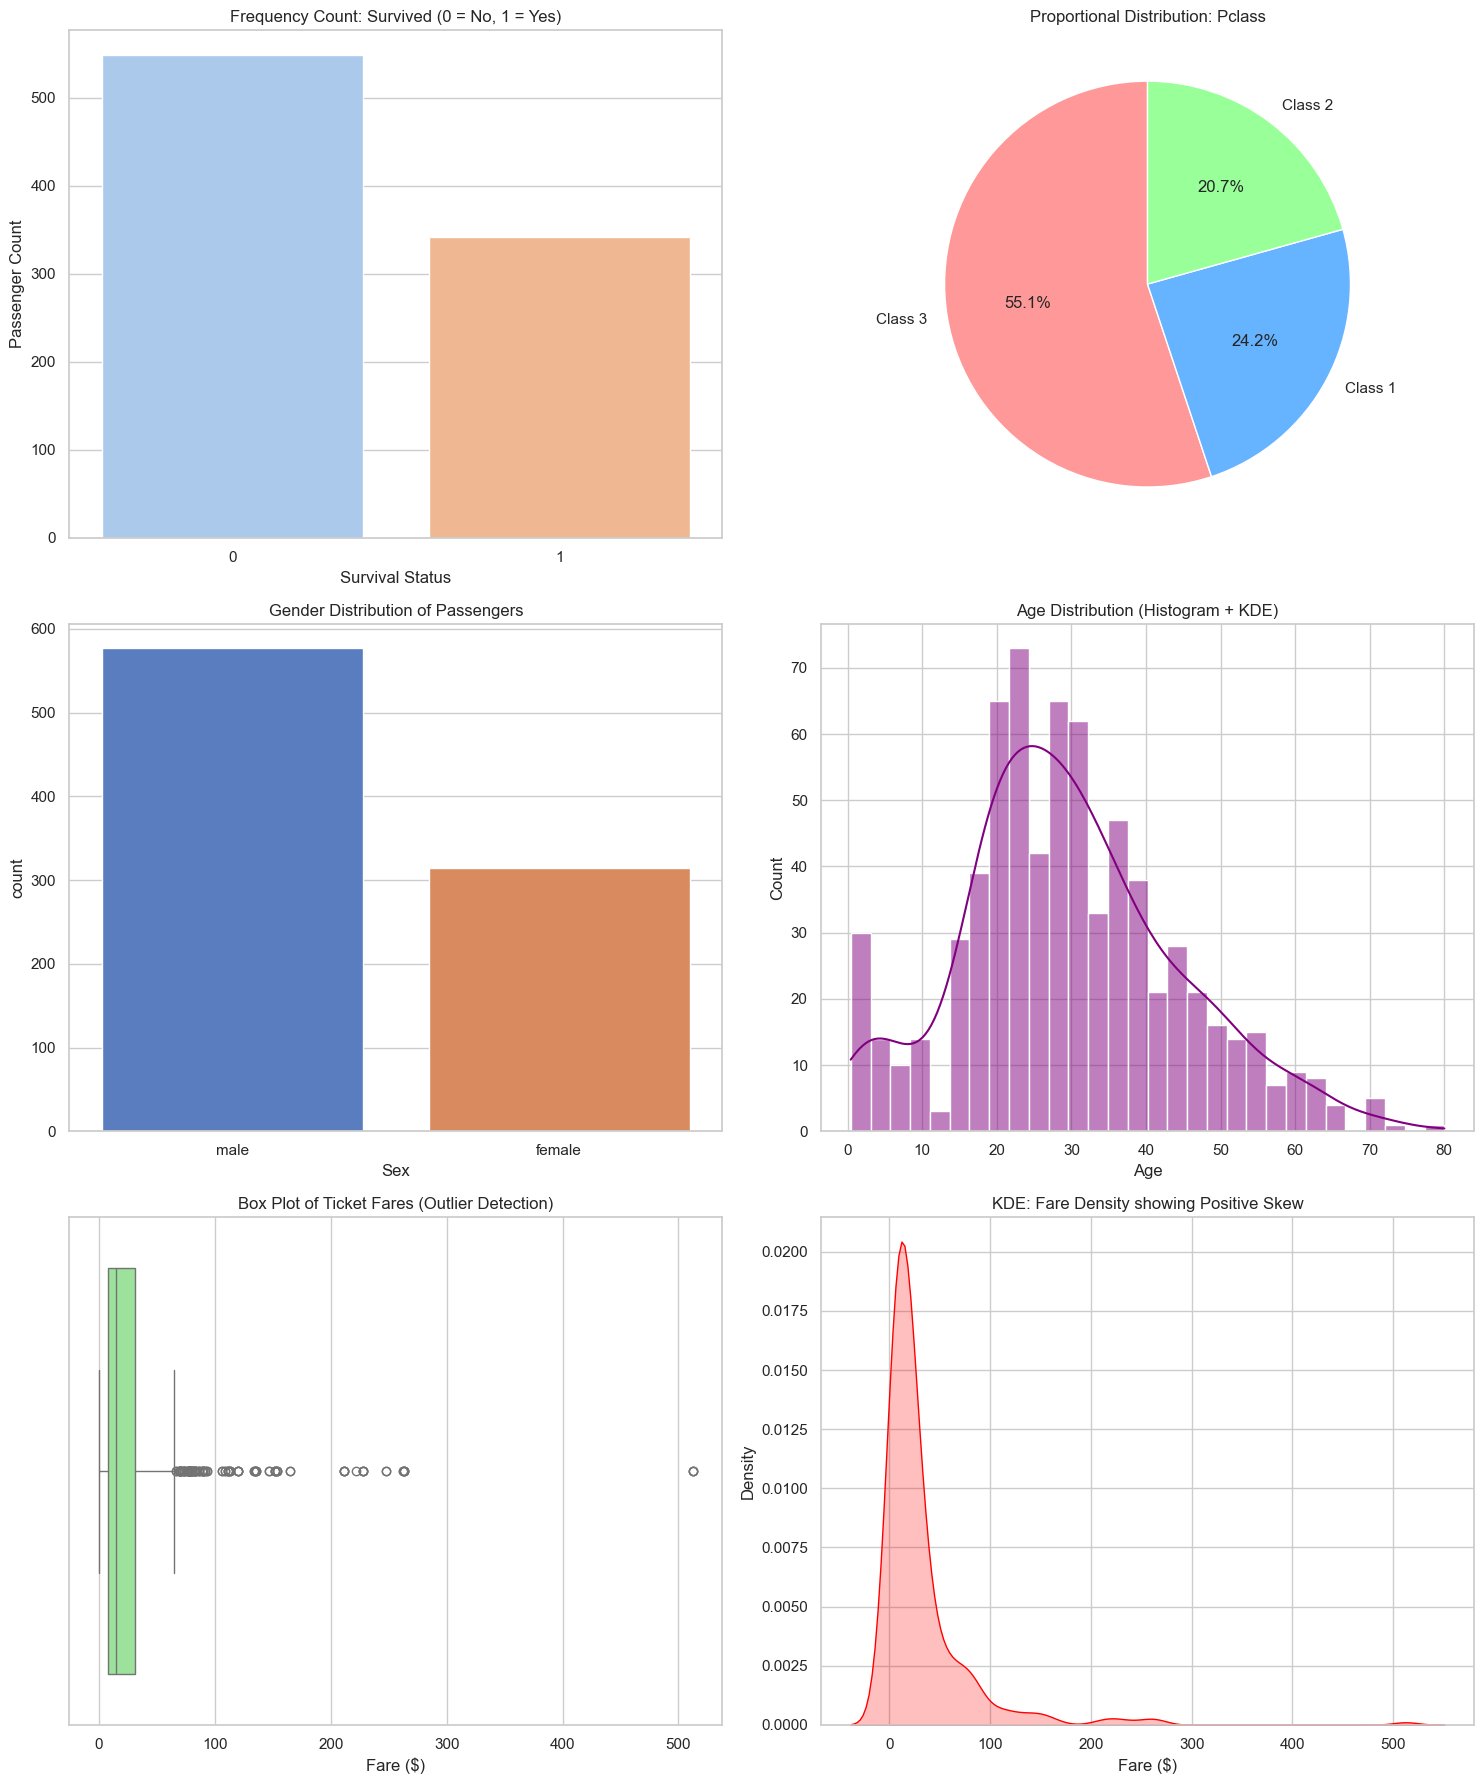

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load Data
url = "../data/titanic.csv"
df = pd.read_csv(url)

# Clean missing values for plotting
df['Age'].fillna(df['Age'].median(), inplace=True)
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)

# Set styling
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(3, 2, figsize=(15, 18))

# ================= CATEGORICAL ANALYSIS =================

# Plot A: Countplot of Survival status
sns.countplot(data=df, x='Survived', ax=axes[0, 0], palette='pastel')
axes[0, 0].set_title('Frequency Count: Survived (0 = No, 1 = Yes)')
axes[0, 0].set_xlabel('Survival Status')
axes[0, 0].set_ylabel('Passenger Count')

# Plot B: Pie Chart of Passenger Class (Pclass)
pclass_counts = df['Pclass'].value_counts()
axes[0, 1].pie(pclass_counts, labels=[f"Class {i}" for i in pclass_counts.index],
               autopct='%1.1f%%', startangle=90, colors=['#ff9999','#66b3ff','#99ff99'])
axes[0, 1].set_title('Proportional Distribution: Pclass')

# Plot C: Countplot of Gender (Sex)
sns.countplot(data=df, x='Sex', ax=axes[1, 0], palette='muted')
axes[1, 0].set_title('Gender Distribution of Passengers')

# ================= NUMERICAL ANALYSIS =================

# Plot D: Histogram & KDE of Passenger Age
sns.histplot(data=df, x='Age', kde=True, bins=30, ax=axes[1, 1], color='purple')
axes[1, 1].set_title('Age Distribution (Histogram + KDE)')
axes[1, 1].set_xlabel('Age')

# Plot E: Boxplot of Passenger Fares
sns.boxplot(data=df, x='Fare', ax=axes[2, 0], color='lightgreen')
axes[2, 0].set_title('Box Plot of Ticket Fares (Outlier Detection)')
axes[2, 0].set_xlabel('Fare ($)')

# Plot F: KDE of Passenger Fares to visualize Skewness
sns.kdeplot(data=df, x='Fare', ax=axes[2, 1], fill=True, color='red')
axes[2, 1].set_title('KDE: Fare Density showing Positive Skew')
axes[2, 1].set_xlabel('Fare ($)')

# Print Mathematical statistics for Numerical columns
print("=== Mathematical Descriptive Stats ===")
print(df[['Age', 'Fare']].describe())

print("\n=== Skewness and Kurtosis ===")
print(f"Age Skewness: {df['Age'].skew():.4f} (Ideal normal ~ 0)")
print(f"Fare Skewness: {df['Fare'].skew():.4f} (Strong positive skew)")
print(f"Fare Kurtosis: {df['Fare'].kurt():.4f} (Very high peak and heavy tail)")

# Show all plots
plt.tight_layout()
plt.show()



---

## 5. Practical Tips and Analogies

> [!NOTE]
> **The Box Plot "Whisker" Myth**: Beginners often think the whiskers of a box plot represent the minimum and maximum values of the dataset. This is incorrect. The whiskers represent the **Fences** ($Q_1 - 1.5 \times \text{IQR}$ and $Q_3 + 1.5 \times \text{IQR}$). Any points plotted beyond the whiskers are mathematically defined outliers.

> [!TIP]
> **Checking Skewness Before Models**: Many algorithms (like Linear Regression) assume that features are normally distributed. If a variable is highly skewed (like `Fare`, skewness $> 1.0$), you will need to apply a mathematical transformation (like a Log transform or Box-Cox) in the feature engineering step to make it normal.
